In [4]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar el dataset sintético
ruta_archivo = '../data/raw/atenciones_essalud.csv'
print(f"Cargando datos desde: {ruta_archivo}")
df = pd.read_csv(ruta_archivo)

# Mostrar la cantidad total de registros y las primeras 5 filas
print(f"Total de registros cargados: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}\n")
display(df.head())

Cargando datos desde: ../data/raw/atenciones_essalud.csv
Total de registros cargados: 500000
Total de columnas: 10



,atencion_id,fecha_atencion,establecimiento_nombre,especialidad,paciente_edad,paciente_sexo,diagnostico_cie10,diagnostico_nombre,diagnostico_grupo,tasa_ocupacion
0,ATN-2023-0000000,2023-07-17,Hospital Sabogal,Medicina Interna,19,F,J06,Infección aguda vías respiratorias,Respiratorias,0.68
1,ATN-2022-0000001,2022-09-16,Hospital Sabogal,Cardiología,89,F,J06,Infección aguda vías respiratorias,Respiratorias,1.12
2,ATN-2024-0000002,2024-03-31,Hospital Almenara,Pediatría,73,F,A90,Dengue (sin signo de alarma),Enfermedades_infecciosas,0.61
3,ATN-2022-0000003,2022-09-02,Hospital Almenara,Pediatría,11,F,J06,Infección aguda vías respiratorias,Respiratorias,0.77
4,ATN-2024-0000004,2024-04-21,Hospital Rebagliati,Medicina Interna,40,M,E11,Diabetes mellitus tipo 2,Crónicas,0.79


C:\Users\Home\AppData\Local\Temp\ipykernel_32352\2831007426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='especialidad', order=df['especialidad'].value_counts().index, palette='viridis')


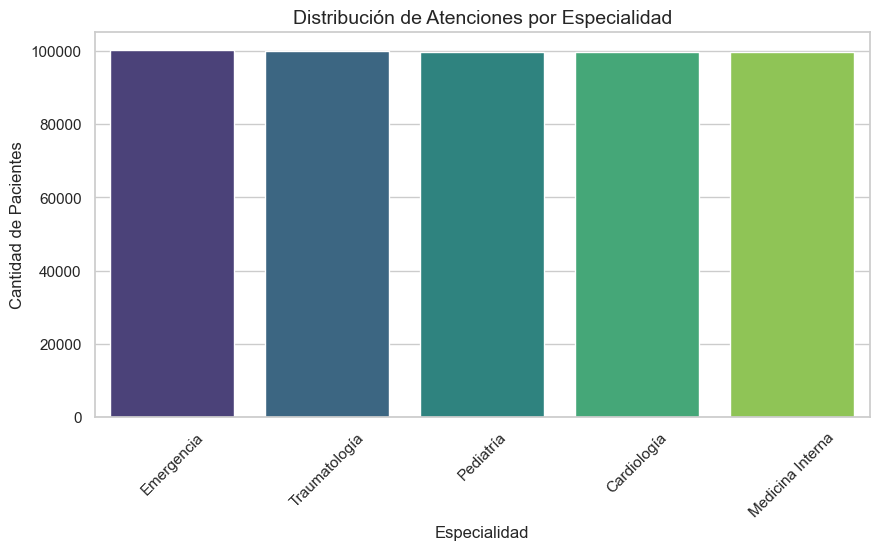

C:\Users\Home\AppData\Local\Temp\ipykernel_32352\2831007426.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='diagnostico_nombre', order=df['diagnostico_nombre'].value_counts().index, palette='magma')


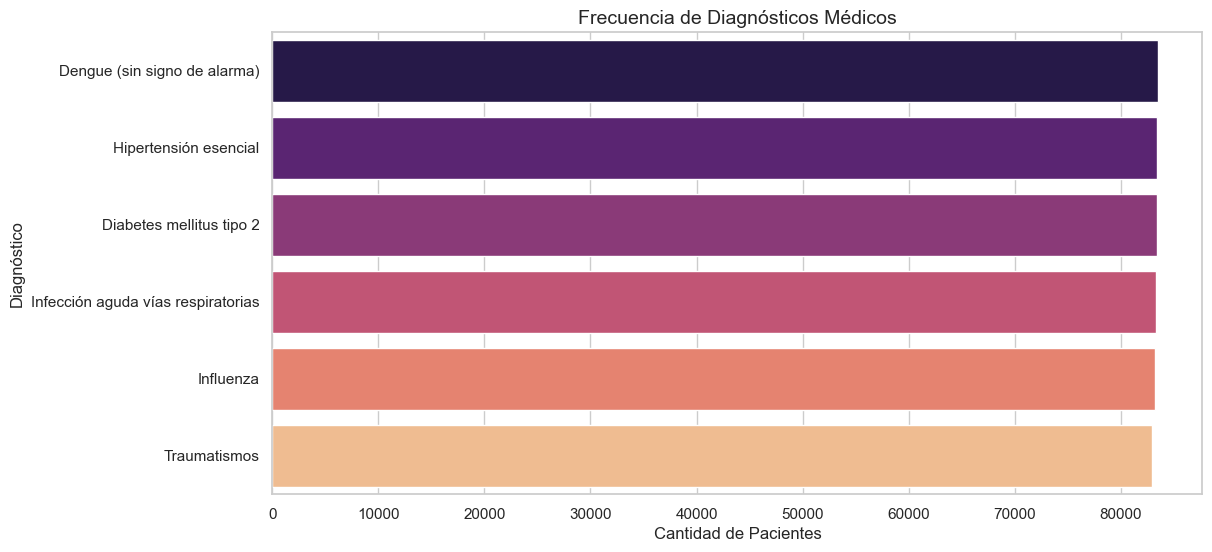

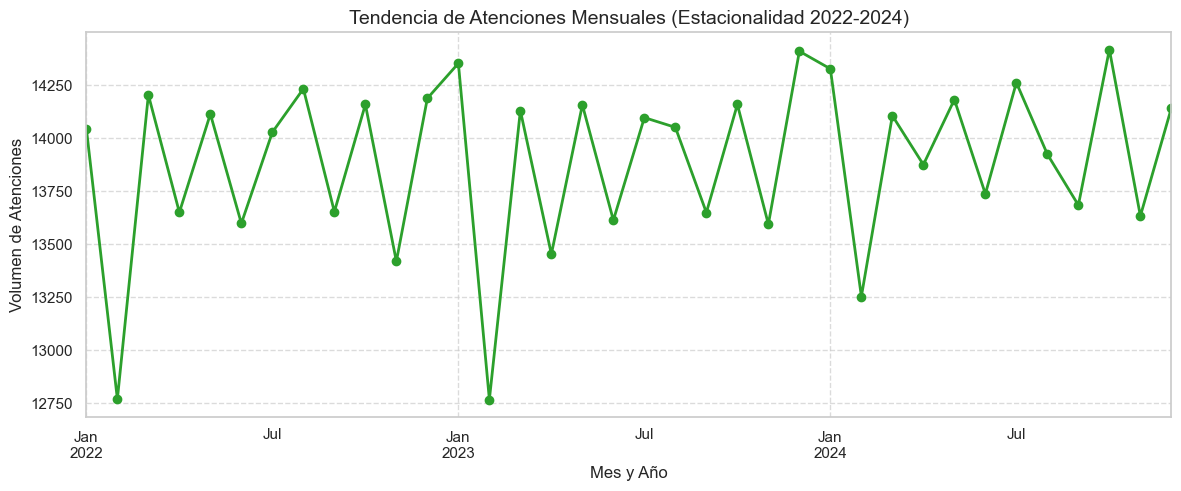

In [5]:
# 2. Análisis de Distribución por Especialidad
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='especialidad', order=df['especialidad'].value_counts().index, palette='viridis')
plt.title('Distribución de Atenciones por Especialidad', fontsize=14)
plt.xlabel('Especialidad', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 3. Top Diagnósticos (Distribución de Enfermedades)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='diagnostico_nombre', order=df['diagnostico_nombre'].value_counts().index, palette='magma')
plt.title('Frecuencia de Diagnósticos Médicos', fontsize=14)
plt.xlabel('Cantidad de Pacientes', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)
plt.show()

# 4. Estacionalidad (Atenciones por mes a lo largo de los años)
# Convertir la columna de fecha a formato datetime para análisis temporal
df['fecha_atencion'] = pd.to_datetime(df['fecha_atencion'])
df['año_mes'] = df['fecha_atencion'].dt.to_period('M')

# Agrupar y contar las atenciones por mes
atenciones_mensuales = df.groupby('año_mes').size()

plt.figure(figsize=(14, 5))
atenciones_mensuales.plot(kind='line', marker='o', color='#2ca02c', linewidth=2)
plt.title('Tendencia de Atenciones Mensuales (Estacionalidad 2022-2024)', fontsize=14)
plt.xlabel('Mes y Año', fontsize=12)
plt.ylabel('Volumen de Atenciones', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()